# Notebook 8: Breast Cancer Wisconsin (Original) - UCI
**Fuente:** https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original

Dataset clásico de diagnóstico de cáncer de mama. Contiene características de núcleos celulares obtenidas mediante aspiración con aguja fina (FNA) para clasificar tumores como benignos o malignos.

## Introducción
El **Breast Cancer Wisconsin (Original)** contiene 699 instancias con 10 atributos numéricos (escala 1-10) que describen características celulares. La variable objetivo (`Class`) es binaria: 2 = benigno, 4 = maligno. Contiene 16 valores faltantes representados como `?` en la columna `Bare_Nuclei`. Es un problema de **clasificación binaria** con alta relevancia médica.

##  Carga del Dataset

In [1]:
import os
import pandas as pd
import numpy as np

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    EXPORT_PATH = '/content/drive/MyDrive/datasets/breast_cancer/'
else:
    EXPORT_PATH = './breast_cancer_output/'

os.makedirs(EXPORT_PATH, exist_ok=True)

URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data'

COLUMNS = [
    'Sample_code_number', 'Clump_Thickness', 'Uniformity_of_Cell_Size',
    'Uniformity_of_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size',
    'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class'
]

df = pd.read_csv(URL, header=None, names=COLUMNS, na_values='?')
print(f'Dataset cargado: {df.shape}')
df.head()

Mounted at /content/drive
Dataset cargado: (699, 11)


,Sample_code_number,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


##  Identificación del Tipo de Problema

In [2]:
TARGET = 'Class'
print(f'Variable objetivo: {TARGET}')
print(f'Valores únicos: {df[TARGET].unique()}')
print(f'Distribución:\n{df[TARGET].value_counts()}')
print('\n→ Tipo de problema: CLASIFICACIÓN BINARIA (2=benigno, 4=maligno)')

Variable objetivo: Class
Valores únicos: [2 4]
Distribución:
Class
2    458
4    241
Name: count, dtype: int64

→ Tipo de problema: CLASIFICACIÓN BINARIA (2=benigno, 4=maligno)


##  Análisis Exploratorio (EDA)

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

df.info()
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Sample_code_number           699 non-null    int64  
 1   Clump_Thickness              699 non-null    int64  
 2   Uniformity_of_Cell_Size      699 non-null    int64  
 3   Uniformity_of_Cell_Shape     699 non-null    int64  
 4   Marginal_Adhesion            699 non-null    int64  
 5   Single_Epithelial_Cell_Size  699 non-null    int64  
 6   Bare_Nuclei                  683 non-null    float64
 7   Bland_Chromatin              699 non-null    int64  
 8   Normal_Nucleoli              699 non-null    int64  
 9   Mitoses                      699 non-null    int64  
 10  Class                        699 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.2 KB


,Sample_code_number,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [5]:
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
Sample_code_number              0
Clump_Thickness                 0
Uniformity_of_Cell_Size         0
Uniformity_of_Cell_Shape        0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


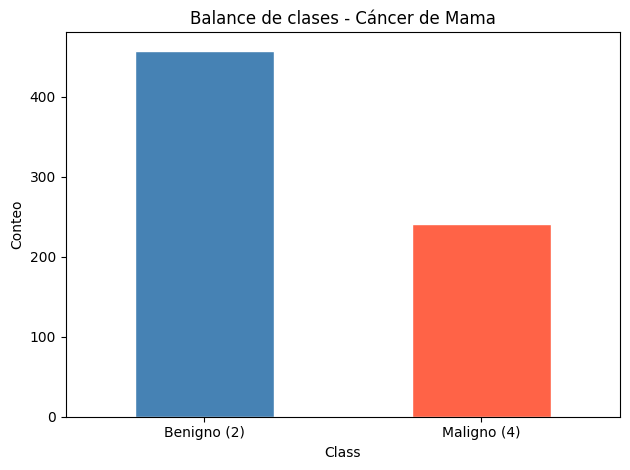

In [6]:
# Balance de clases
df[TARGET].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='white')
plt.title('Balance de clases - Cáncer de Mama')
plt.xticks([0,1], ['Benigno (2)', 'Maligno (4)'], rotation=0)
plt.ylabel('Conteo')
plt.tight_layout()
plt.show()

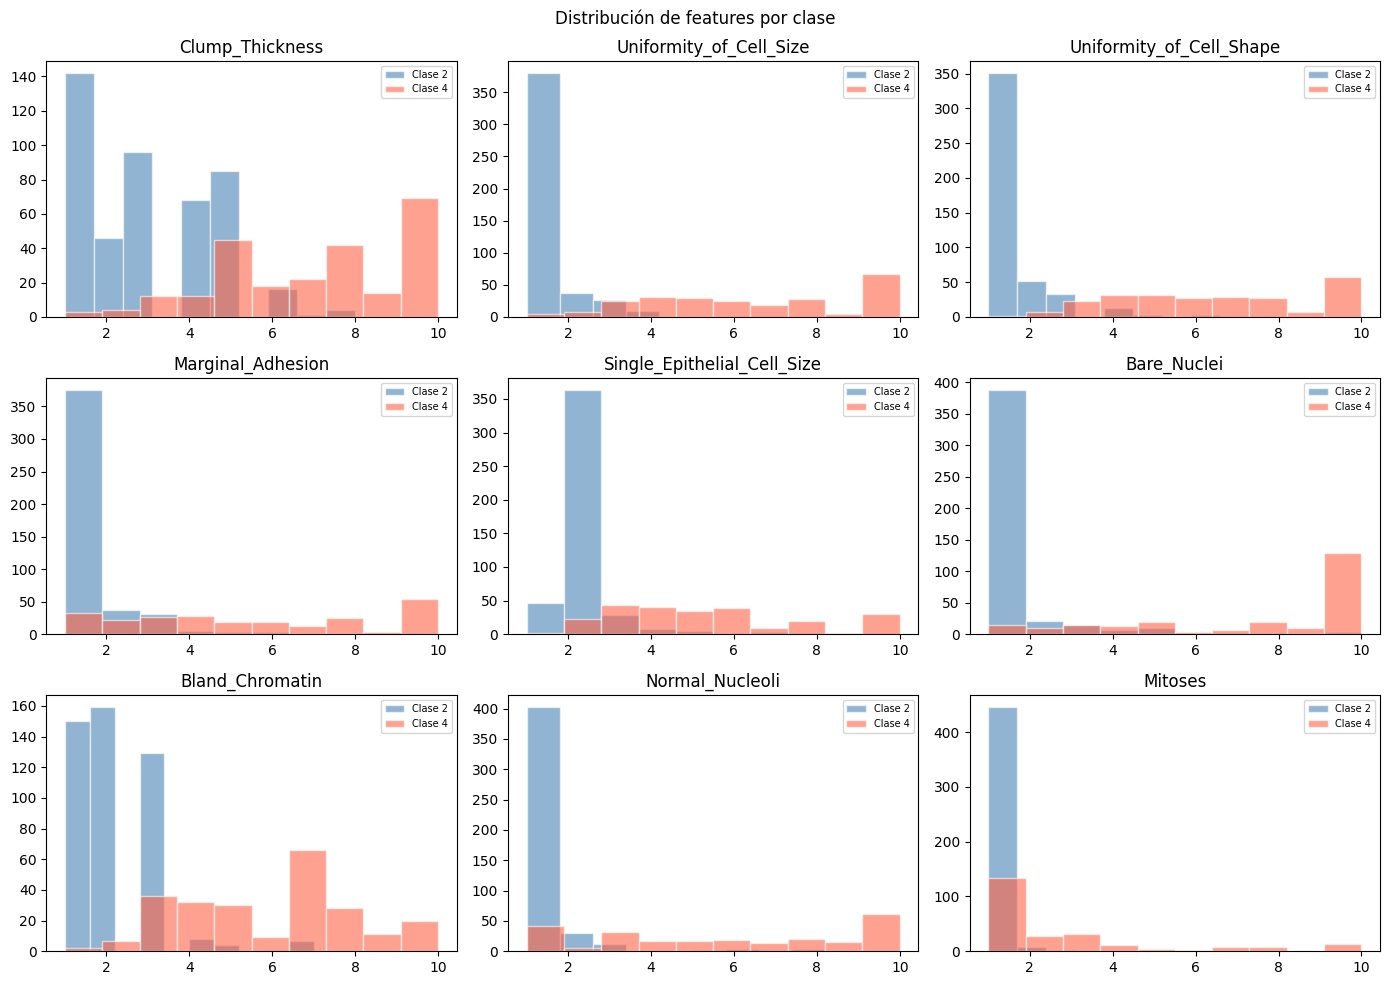

In [7]:
# Distribuciones de features por clase
features = [c for c in df.columns if c not in ['Sample_code_number', TARGET]]
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(features):
    for cls, color in zip([2, 4], ['steelblue', 'tomato']):
        subset = df[df[TARGET] == cls][col].dropna()
        axes[i].hist(subset, bins=10, alpha=0.6, color=color, label=f'Clase {cls}', edgecolor='white')
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)
plt.suptitle('Distribución de features por clase')
plt.tight_layout()
plt.show()

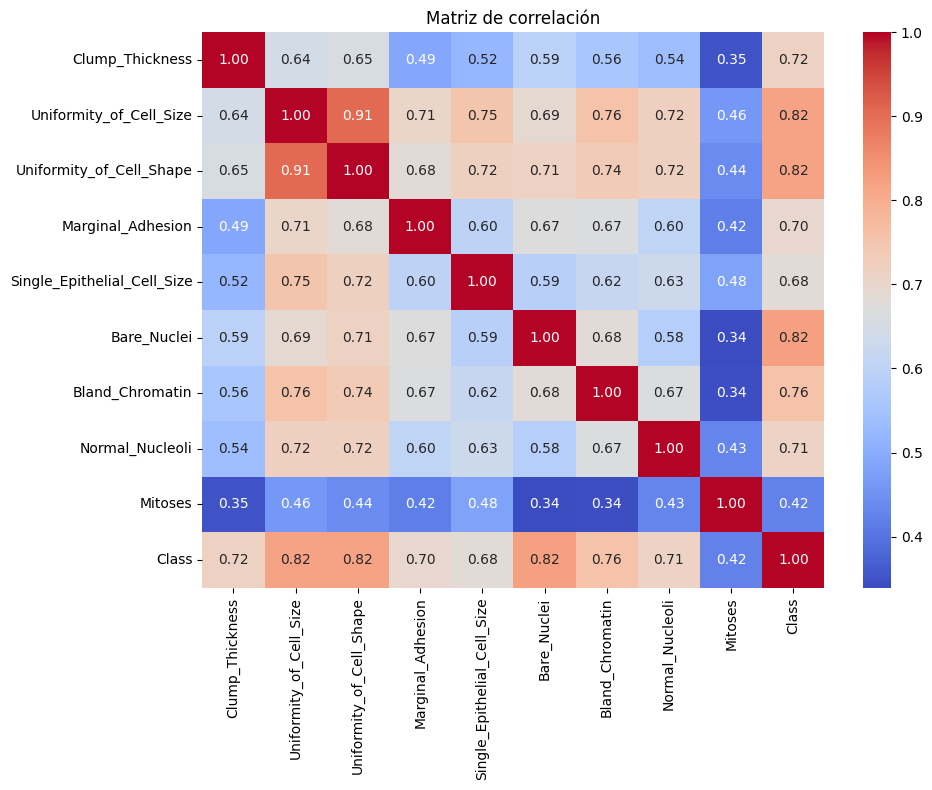

In [8]:
# Correlaciones
df_corr = df.drop(columns=['Sample_code_number']).copy()
df_corr['Bare_Nuclei'] = pd.to_numeric(df_corr['Bare_Nuclei'], errors='coerce')
plt.figure(figsize=(10,8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

## Limpieza y Preparación

In [9]:
df_clean = df.copy()

# Eliminar columna ID (no predictiva)
df_clean = df_clean.drop(columns=['Sample_code_number'])

# Convertir Bare_Nuclei a numérico
df_clean['Bare_Nuclei'] = pd.to_numeric(df_clean['Bare_Nuclei'], errors='coerce')

# Eliminar duplicados
print(f'Duplicados: {df_clean.duplicated().sum()}')
df_clean = df_clean.drop_duplicates()

# Imputar nulos con mediana (16 valores en Bare_Nuclei)
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'  {col}: imputado con mediana = {median_val}')

print(f'Nulos restantes: {df_clean.isnull().sum().sum()}')
print(f'Shape final: {df_clean.shape}')

Duplicados: 236
  Bare_Nuclei: imputado con mediana = 3.0
Nulos restantes: 0
Shape final: (463, 10)


/tmp/ipykernel_1376/4265570614.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(median_val, inplace=True)


##  Transformación y Preprocesamiento

In [10]:
from sklearn.preprocessing import StandardScaler

df_processed = df_clean.copy()

# Recodificar target: 2 → 0 (benigno), 4 → 1 (maligno)
df_processed[TARGET] = df_processed[TARGET].map({2: 0, 4: 1})
print(f'Target recodificado: 0=benigno, 1=maligno')
print(df_processed[TARGET].value_counts())

feature_cols = [c for c in df_processed.columns if c != TARGET]
scaler = StandardScaler()
df_processed[feature_cols] = scaler.fit_transform(df_processed[feature_cols])

print(f'Shape preprocesado: {df_processed.shape}')
df_processed.head()

Target recodificado: 0=benigno, 1=maligno
Class
1    238
0    225
Name: count, dtype: int64
Shape preprocesado: (463, 10)


,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,-0.112858,-0.981089,-1.038913,-0.854637,-0.752852,-0.979626,-0.444067,-0.828985,-0.433845,0
1,-0.112858,-0.054060,-0.076880,0.415658,1.292749,1.370462,-0.444067,-0.533284,-0.433845,0
2,-0.809565,-0.981089,-1.038913,-0.854637,-0.752852,-0.718505,-0.444067,-0.828985,-0.433845,0
3,0.235496,1.181979,1.205832,-0.854637,-0.343732,-0.196264,-0.444067,0.945221,-0.433845,0
4,-0.461211,-0.981089,-1.038913,-0.219489,-0.752852,-0.979626,-0.444067,-0.828985,-0.433845,0


## División Train/Test (80/20, stratify)

In [11]:
from sklearn.model_selection import train_test_split

X = df_processed.drop(columns=[TARGET])
y = df_processed[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

train_df = X_train.copy(); train_df[TARGET] = y_train.values
test_df  = X_test.copy();  test_df[TARGET]  = y_test.values

print(f'Train: {train_df.shape}  |  Test: {test_df.shape}')
print(f'Proporción malignos - Train: {y_train.mean():.3f}  |  Test: {y_test.mean():.3f}')

Train: (370, 10)  |  Test: (93, 10)
Proporción malignos - Train: 0.514  |  Test: 0.516


## Exportación de train.csv y test.csv

In [12]:
train_df.to_csv(os.path.join(EXPORT_PATH, 'train.csv'), index=False)
test_df.to_csv(os.path.join(EXPORT_PATH, 'test.csv'), index=False)
print(f'✅ train.csv guardado: {train_df.shape}')
print(f'✅ test.csv  guardado: {test_df.shape}')

✅ train.csv guardado: (370, 10)
✅ test.csv  guardado: (93, 10)
